In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('hr_attrition_cleaned.csv')
print("Shape:", df.shape)

Shape: (1470, 34)


In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

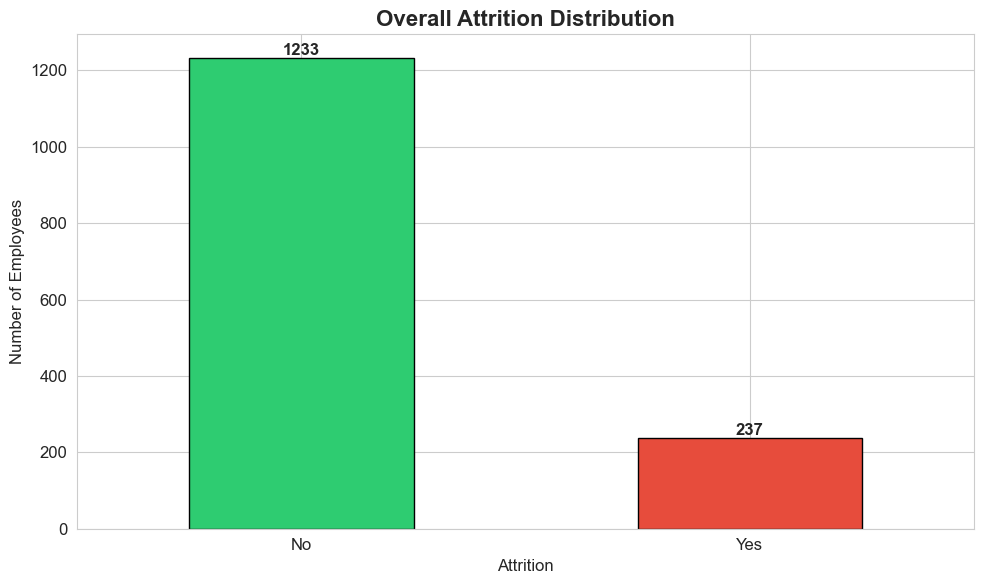

In [3]:
colors = ['#2ecc71', '#e74c3c']

ax = df['Attrition'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Overall Attrition Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)

# Add numbers on top of bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('01_attrition_distribution.png', dpi=150)
plt.show()

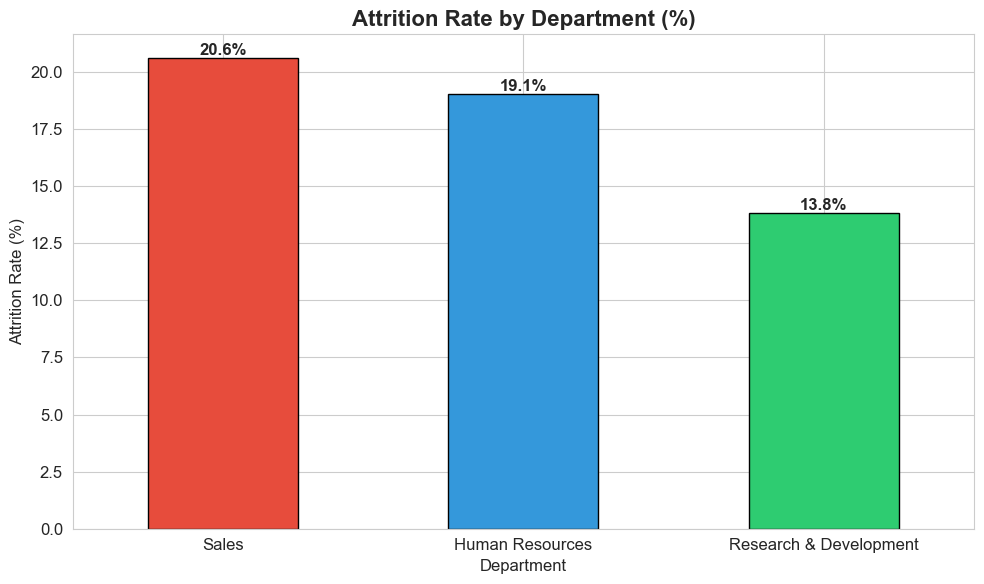

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: AttritionFlag, dtype: float64


In [4]:
dept_attrition = df.groupby('Department')['AttritionFlag'].mean() * 100
dept_attrition = dept_attrition.round(2).sort_values(ascending=False)

ax = dept_attrition.plot(kind='bar', color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')
plt.title('Attrition Rate by Department (%)', fontsize=16, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('02_attrition_by_department.png', dpi=150)
plt.show()

print(dept_attrition)

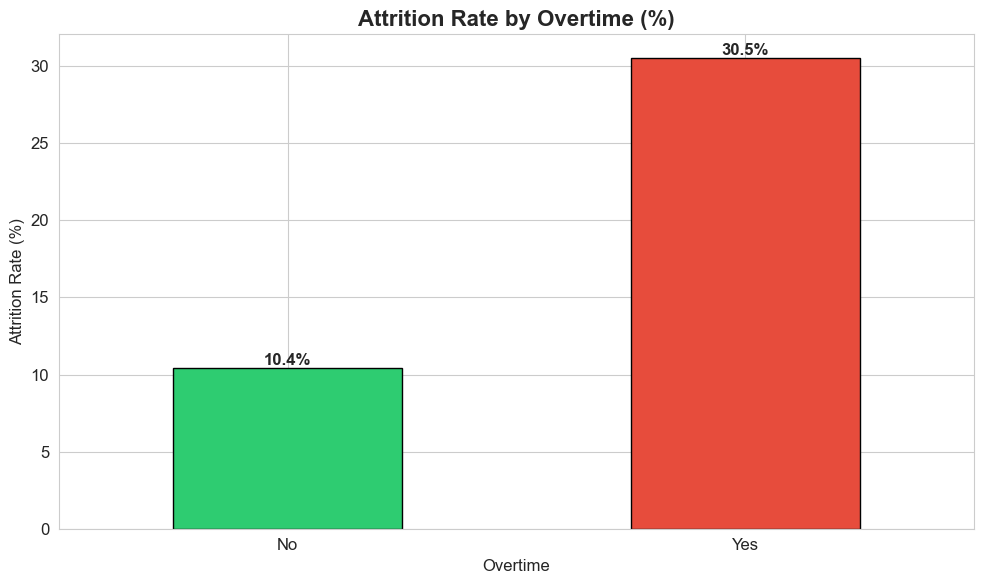

OverTime
No     10.44
Yes    30.53
Name: AttritionFlag, dtype: float64


In [5]:
overtime_attrition = df.groupby('OverTime')['AttritionFlag'].mean() * 100
overtime_attrition = overtime_attrition.round(2)

ax = overtime_attrition.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black')
plt.title('Attrition Rate by Overtime (%)', fontsize=16, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('03_attrition_by_overtime.png', dpi=150)
plt.show()

print(overtime_attrition)

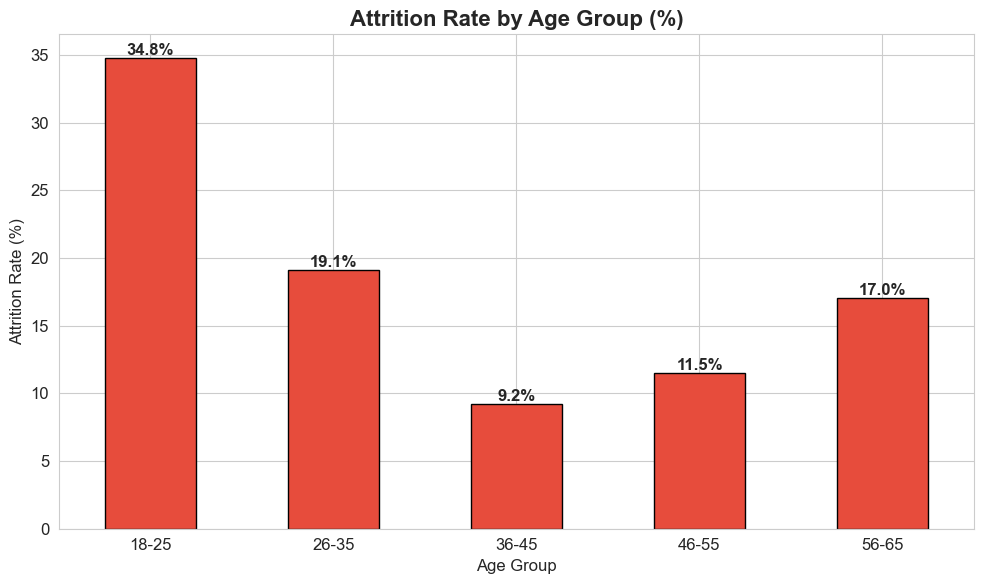

AgeGroup
18-25    34.78
26-35    19.14
36-45     9.19
46-55    11.50
56-65    17.02
Name: AttritionFlag, dtype: float64


In [6]:
# Create age groups
bins = [18, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_attrition = df.groupby('AgeGroup', observed=True)['AttritionFlag'].mean() * 100
age_attrition = age_attrition.round(2)

ax = age_attrition.plot(kind='bar', color='#e74c3c', edgecolor='black')
plt.title('Attrition Rate by Age Group (%)', fontsize=16, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('04_attrition_by_age.png', dpi=150)
plt.show()

print(age_attrition)

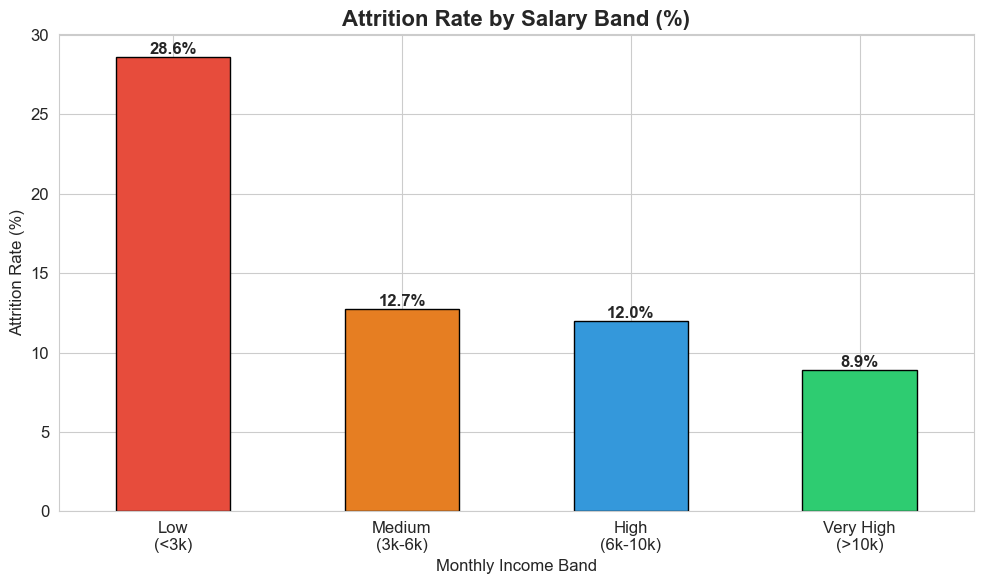

SalaryBand
Low\n(<3k)           28.61
Medium\n(3k-6k)      12.72
High\n(6k-10k)       12.00
Very High\n(>10k)     8.90
Name: AttritionFlag, dtype: float64


In [7]:
# Create salary bands
df['SalaryBand'] = pd.cut(df['MonthlyIncome'],
                           bins=[0, 3000, 6000, 10000, 20000],
                           labels=['Low\n(<3k)', 'Medium\n(3k-6k)', 'High\n(6k-10k)', 'Very High\n(>10k)'])

salary_attrition = df.groupby('SalaryBand', observed=True)['AttritionFlag'].mean() * 100
salary_attrition = salary_attrition.round(2)

ax = salary_attrition.plot(kind='bar', color=['#e74c3c','#e67e22','#3498db','#2ecc71'], edgecolor='black')
plt.title('Attrition Rate by Salary Band (%)', fontsize=16, fontweight='bold')
plt.xlabel('Monthly Income Band')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('05_attrition_by_salary.png', dpi=150)
plt.show()

print(salary_attrition)

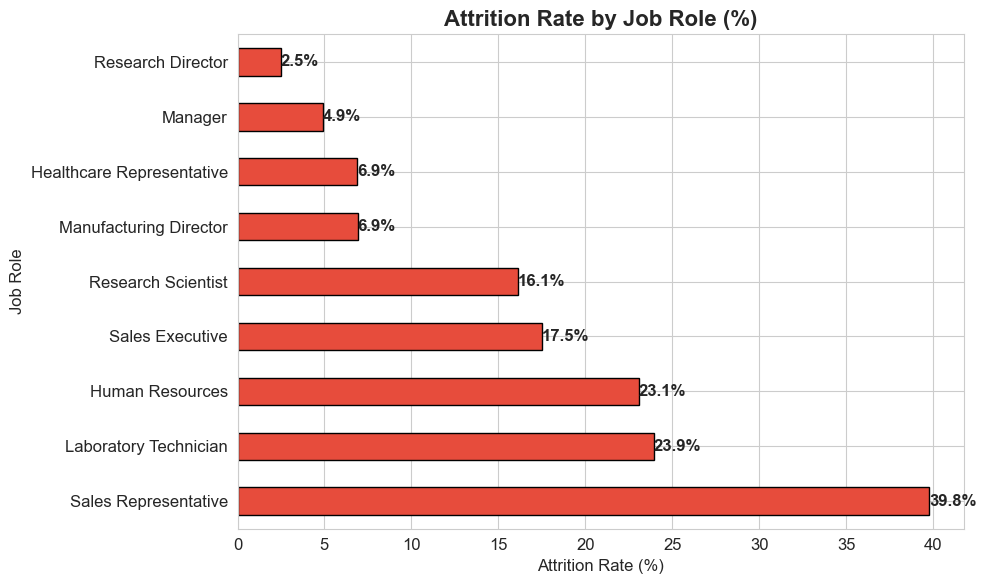

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: AttritionFlag, dtype: float64


In [8]:
role_attrition = df.groupby('JobRole')['AttritionFlag'].mean() * 100
role_attrition = role_attrition.round(2).sort_values(ascending=False)

ax = role_attrition.plot(kind='barh', color='#e74c3c', edgecolor='black')
plt.title('Attrition Rate by Job Role (%)', fontsize=16, fontweight='bold')
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')

for p in ax.patches:
    ax.annotate(f"{p.get_width():.1f}%",
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('06_attrition_by_jobrole.png', dpi=150)
plt.show()

print(role_attrition)

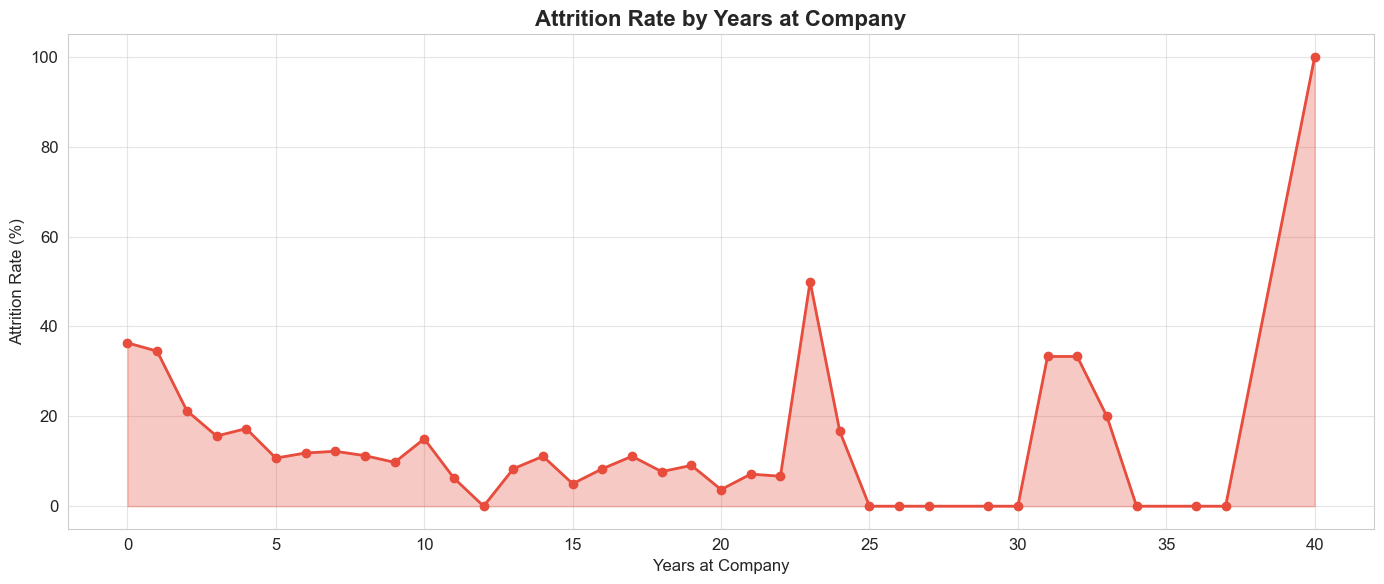

In [9]:
years_attrition = df.groupby('YearsAtCompany')['AttritionFlag'].mean() * 100
years_attrition = years_attrition.round(2)

plt.figure(figsize=(14, 6))
plt.plot(years_attrition.index, years_attrition.values, 
         color='#e74c3c', marker='o', linewidth=2, markersize=6)
plt.fill_between(years_attrition.index, years_attrition.values, alpha=0.3, color='#e74c3c')
plt.title('Attrition Rate by Years at Company', fontsize=16, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.savefig('07_attrition_by_tenure.png', dpi=150)
plt.show()

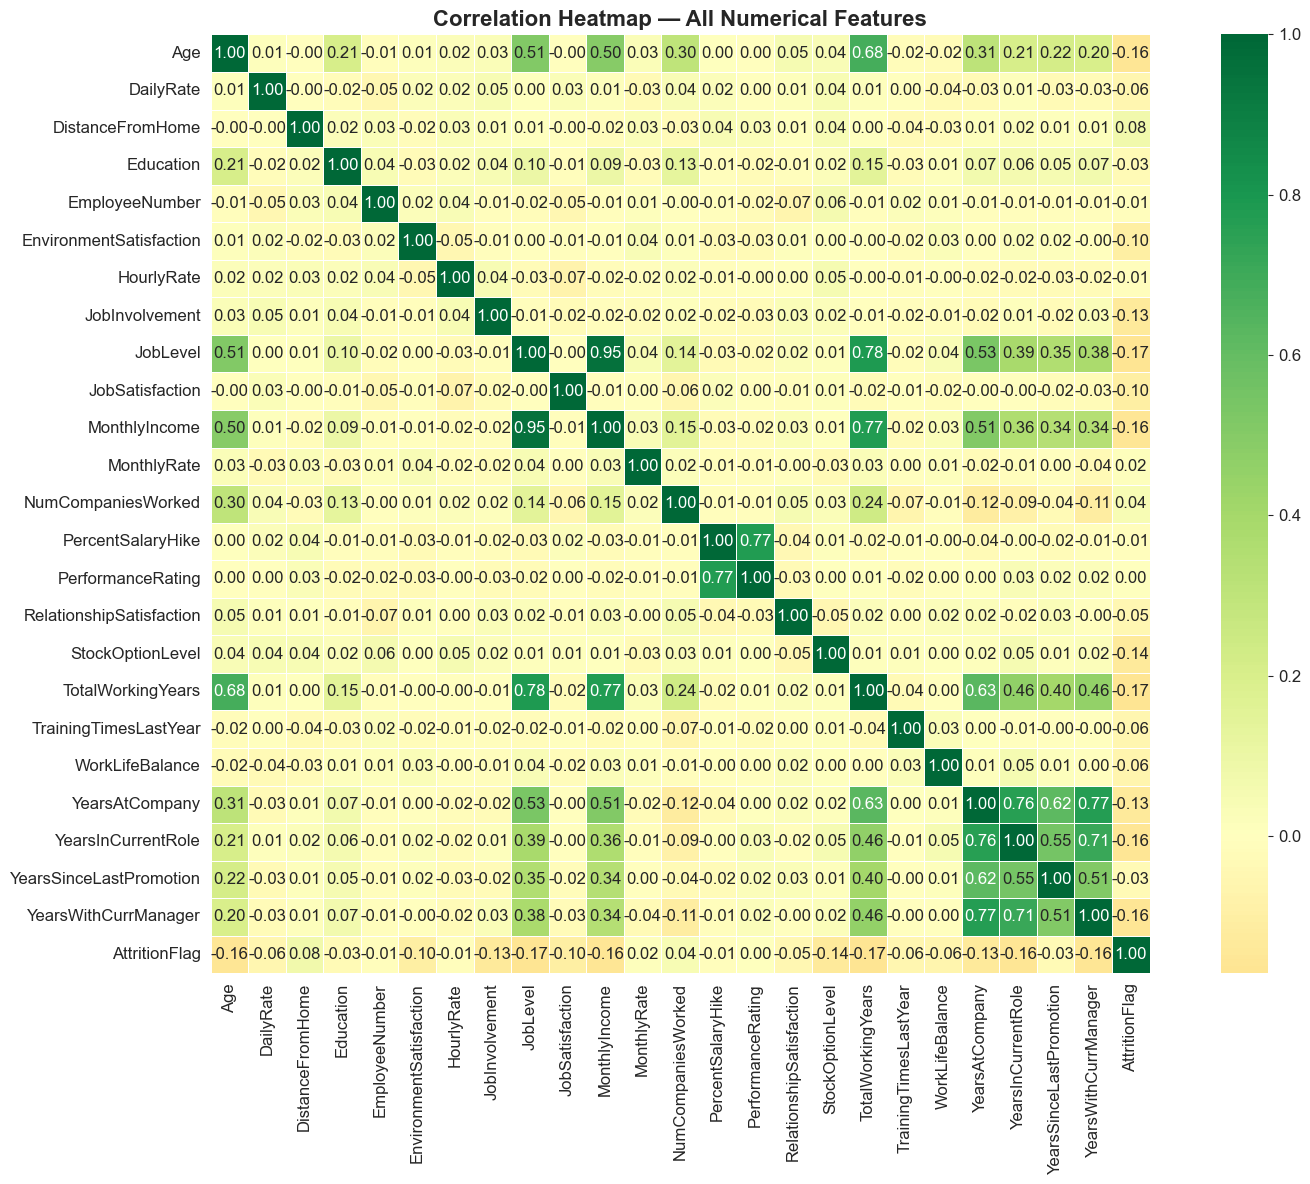

In [10]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(16, 12))
correlation = df[numerical_cols].corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap — All Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('08_correlation_heatmap.png', dpi=150)
plt.show()

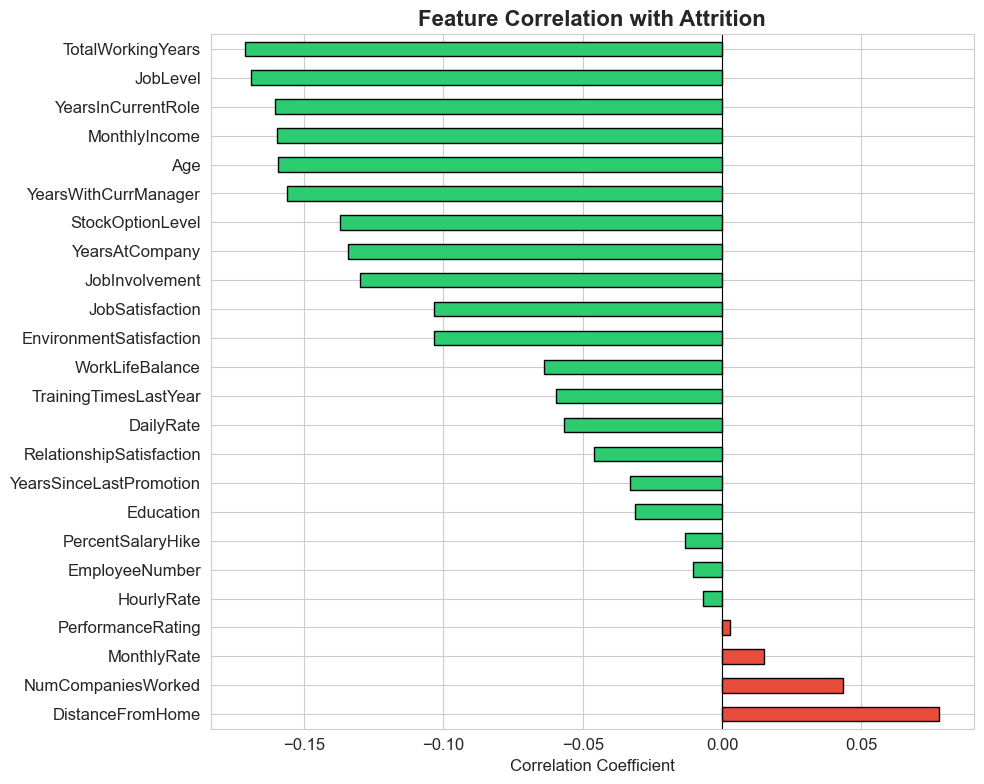

DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: AttritionFlag, dtype: float64


In [11]:
# Sort by correlation with AttritionFlag
attrition_corr = correlation['AttritionFlag'].drop('AttritionFlag')
attrition_corr = attrition_corr.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in attrition_corr.values]
attrition_corr.plot(kind='barh', color=colors, edgecolor='black')

plt.title('Feature Correlation with Attrition', fontsize=16, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('09_attrition_correlation.png', dpi=150)
plt.show()

print(attrition_corr)

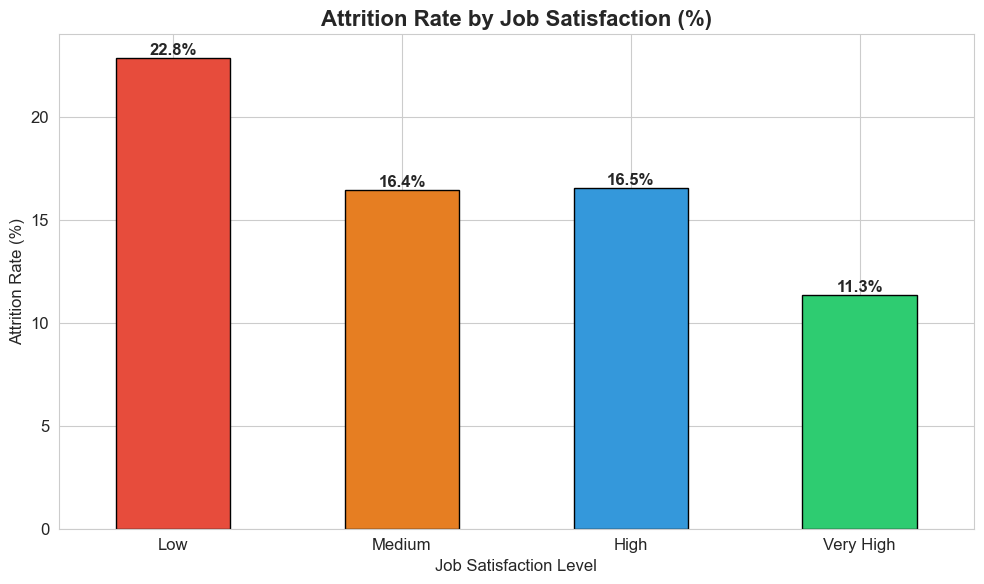

Low          22.84
Medium       16.43
High         16.52
Very High    11.33
Name: AttritionFlag, dtype: float64


In [12]:
satisfaction_attrition = df.groupby('JobSatisfaction')['AttritionFlag'].mean() * 100
satisfaction_attrition = satisfaction_attrition.round(2)

# Map numbers to labels
satisfaction_attrition.index = ['Low', 'Medium', 'High', 'Very High']

ax = satisfaction_attrition.plot(kind='bar', 
                                  color=['#e74c3c','#e67e22','#3498db','#2ecc71'], 
                                  edgecolor='black')
plt.title('Attrition Rate by Job Satisfaction (%)', fontsize=16, fontweight='bold')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('10_attrition_by_satisfaction.png', dpi=150)
plt.show()

print(satisfaction_attrition)

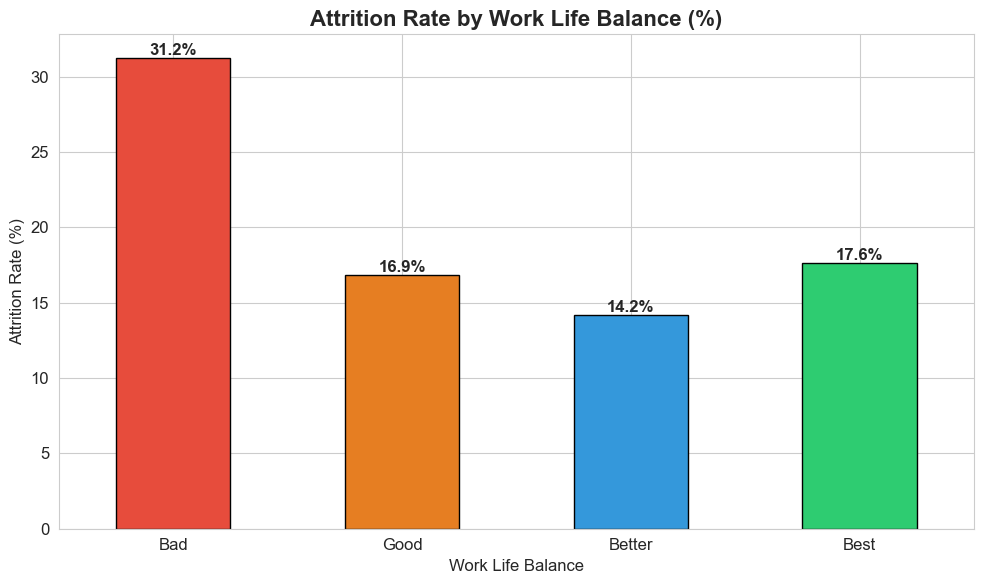

Bad       31.25
Good      16.86
Better    14.22
Best      17.65
Name: AttritionFlag, dtype: float64


In [13]:
worklife_attrition = df.groupby('WorkLifeBalance')['AttritionFlag'].mean() * 100
worklife_attrition = worklife_attrition.round(2)

worklife_attrition.index = ['Bad', 'Good', 'Better', 'Best']

ax = worklife_attrition.plot(kind='bar',
                              color=['#e74c3c','#e67e22','#3498db','#2ecc71'],
                              edgecolor='black')
plt.title('Attrition Rate by Work Life Balance (%)', fontsize=16, fontweight='bold')
plt.xlabel('Work Life Balance')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('11_attrition_by_worklife.png', dpi=150)
plt.show()

print(worklife_attrition)

In [14]:
print(df['WorkLifeBalance'].value_counts())

WorkLifeBalance
3    893
2    344
4    153
1     80
Name: count, dtype: int64


In [15]:
# Cell 14 — Save final EDA dataframe
df.to_csv('hr_attrition_eda.csv', index=False)
print("EDA complete! Data saved.")
print(f"Total charts created: 11")


EDA complete! Data saved.
Total charts created: 11
